1. Introduction
In a competitive business environment, firms invest heavily in advertising across multiple media channels such as television, radio, and newspapers. This study aims to analyze how different advertising expenditures influence product sales and to determine which medium delivers the highest return.

In [2]:
import pandas as pd

df = pd.read_csv("Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


2. Objective
The objective of this study is to:
Analyze relationships between advertising channels and sales
Perform hypothesis testing
Build a multiple linear regression model
Provide business recommendations

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
3. Dataset Description
The dataset contains 200 observations with the following variables:
Independent Variables:
TV advertising budget
Radio advertising budget
Newspaper advertising budget
Dependent Variable:
Sales
Two additional engineered features were created:
Total advertising spend
TV-radio interaction effect

SyntaxError: invalid syntax (1947750603.py, line 1)

In [5]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


Correlation Analysis

To understand the relationships between variables in the dataset, a correlation heatmap is generated. Correlation measures the strength and direction of a linear relationship between two variables, with values ranging from -1 to +1.

+1 → Perfect positive relationship

0 → No relationship

-1 → Perfect negative relationship

The heatmap visually represents correlations between the advertising budgets (TV, radio, newspaper) and sales. Stronger correlations indicate that changes in advertising spending are more strongly associated with changes in sales.

Scatter plots are also used to visually inspect the relationship between each advertising medium and sales. These plots help confirm whether the relationship appears linear, which is an important assumption for linear regression.

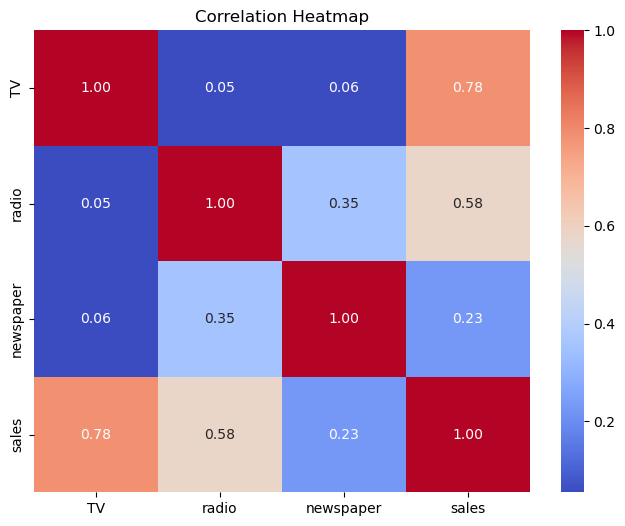

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Train-Test Split and Model Training

To build a predictive model, the dataset is divided into training and testing subsets using an 80–20 split.

Training set (80%) → Used to train the regression model

Testing set (20%) → Used to evaluate how well the model generalizes to unseen data

A Multiple Linear Regression model is then trained using three independent variables:

TV advertising budget

Radio advertising budget

Newspaper advertising budget

The model learns the relationship between these variables and the dependent variable sales, estimating coefficients that represent the expected change in sales for a one-unit increase in advertising spend.

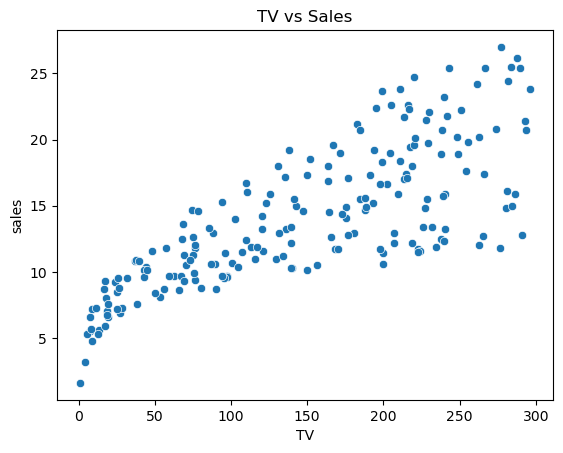

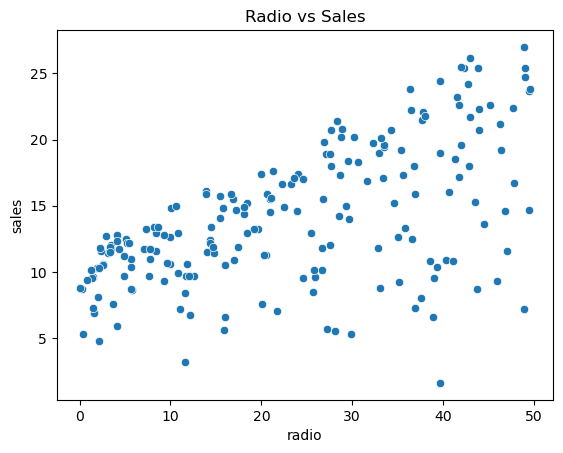

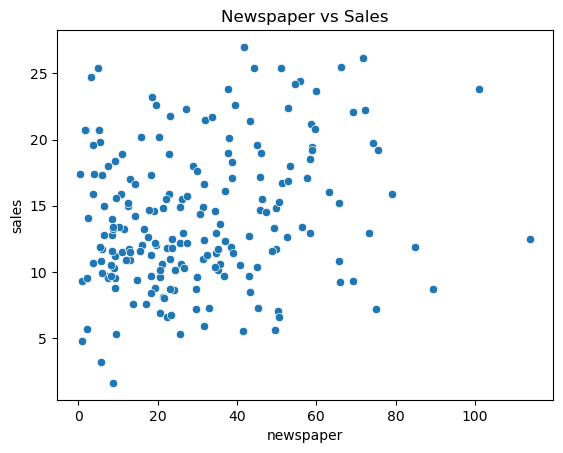

In [7]:
sns.scatterplot(x="TV", y="sales", data=df)
plt.title("TV vs Sales")
plt.show()

sns.scatterplot(x="radio", y="sales", data=df)
plt.title("Radio vs Sales")
plt.show()

sns.scatterplot(x="newspaper", y="sales", data=df)
plt.title("Newspaper vs Sales")
plt.show()

Model Evaluation

The model’s performance is evaluated using the R-squared (R²) metric.

R² = 0.8994

This means that approximately 89.9% of the variation in sales is explained by the advertising variables included in the model. A high R² value indicates that the model provides a strong fit to the data.

The regression coefficients indicate the contribution of each advertising medium:

TV: 0.0447 → Every additional unit spent on TV advertising increases sales by approximately 0.0447 units, holding other variables constant.

Radio: 0.1892 → Radio advertising has the largest positive impact on sales among the predictors.

Newspaper: 0.0028 → Newspaper advertising has a very small effect on sales.

The intercept (≈ 2.98) represents the expected sales value when all advertising expenditures are zero.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R-squared:", r2_score(y_test, y_pred))

print("\nRegression Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

print("Intercept:", model.intercept_)

R-squared: 0.899438024100912

Regression Coefficients:
TV: 0.0447
radio: 0.1892
newspaper: 0.0028
Intercept: 2.979067338122631


Statistical Significance and Model Summary

To obtain detailed statistical insights, the regression model is also evaluated using Ordinary Least Squares (OLS) from the statsmodels library.

The Adjusted R-squared value is 0.8956, which accounts for the number of predictors in the model and provides a more reliable measure of model performance.

Key findings from the regression summary:

TV advertising has a highly significant effect on sales (p < 0.001).

Radio advertising is also highly significant (p < 0.001) and shows a strong positive impact.

Newspaper advertising is not statistically significant (p = 0.860), indicating that it does not meaningfully contribute to predicting sales in this dataset.

The F-statistic (570.3) and extremely small p-value confirm that the overall regression model is statistically significant.

In [9]:
import statsmodels.api as sm

X_sm = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()

print("Adjusted R-Squared:", model_sm.rsquared_adj)
print(model_sm.summary())

Adjusted R-Squared: 0.8956373316204668
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           1.58e-96
Time:                        02:56:29   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

Multicollinearity Check (VIF Analysis)

To ensure that the independent variables do not strongly correlate with each other, a Variance Inflation Factor (VIF) analysis is conducted.

VIF measures how much the variance of a regression coefficient increases due to multicollinearity.

Interpretation guidelines:

VIF = 1 → No multicollinearity

VIF between 1–5 → Moderate but acceptable

VIF > 10 → Serious multicollinearity problem

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data

,Feature,VIF
0,const,6.848900
1,TV,1.004611
2,radio,1.144952
3,newspaper,1.145187


All predictor variables have VIF values close to 1, indicating no multicollinearity issues. This means the advertising variables are sufficiently independent and suitable for use in the regression model.

Residual Analysis

After training the regression model, residual analysis is performed to evaluate how well the model fits the data.

Residuals are the differences between the actual values and the predicted values:
residual = actual - predicted

Plotting residuals against predicted values helps verify key assumptions of linear regression:

Residuals should be randomly scattered around zero

There should be no clear patterns or trends

The spread of residuals should remain relatively constant

If these conditions are satisfied, it indicates that the model captures the relationship between the variables appropriately and that the linearity and homoscedasticity assumptions are reasonably met.

A horizontal reference line at 0 is added to clearly observe whether residuals are balanced around zero.

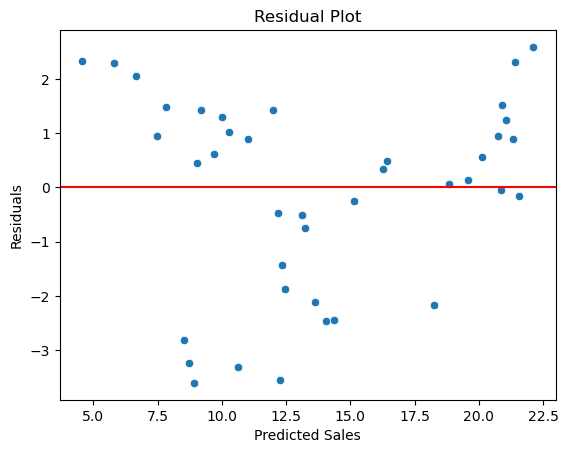

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

To further assess the model, the distribution of residuals is visualized using a histogram with a Kernel Density Estimate (KDE).

In a well-performing linear regression model:

Residuals should be approximately normally distributed

The distribution should be centered around zero

A normal residual distribution suggests that the model errors are random and unbiased, supporting the normality assumption of linear regression.

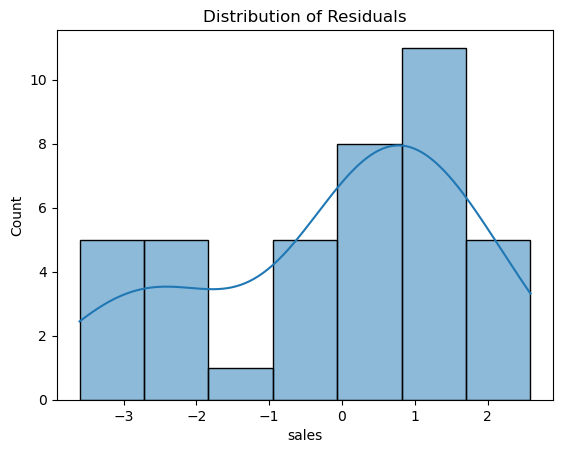

In [13]:
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

Reduced Model (Removing Newspaper Advertising)

Based on the earlier regression results, newspaper advertising showed no statistically significant effect on sales (p-value ≈ 0.860).

To test whether the model can be simplified, a second regression model is created using only the two significant predictors:

TV advertising

Radio advertising

This reduced model helps evaluate whether removing the newspaper variable:

Maintains similar predictive power

Simplifies the model

Improves interpretability

By comparing the model summaries, we can determine whether TV and radio advertising alone are sufficient to explain most of the variation in sales.

In [14]:
X2 = df[["TV", "radio"]]
X2_sm = sm.add_constant(X2)
model2 = sm.OLS(y, X2_sm).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           4.83e-98
Time:                        02:57:19   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9211      0.294      9.919      0.0